# 09 - Class Example

[Link to UCI Repository](https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition)

This dataset include data for the estimation of obesity levels in individuals from the countries of Mexico, Peru and Colombia, based on their eating habits and physical condition. The data contains 17 attributes and 2111 records, the records are labeled with the class variable NObesity (Obesity Level), that allows classification of the data using the values of Insufficient Weight, Normal Weight, Overweight Level I, Overweight Level II, Obesity Type I, Obesity Type II and Obesity Type III. 77% of the data was generated synthetically using the Weka tool and the SMOTE filter, 23% of the data was collected directly from users through a web platform.

Our goal is to build a model that can predict obesity level.

## The Variables

- Gender
- Age
- Height
- Weight
- family_history_with_overweight: Has a family member suffered or suffers from overweight?
- FAVC: Do you eat high caloric food frequently?
- FCVC: Do you usually eat vegetables in your meals?
- NCP: How many main meals do you have daily?
- CAEC: Do you eat any food between meals?
- SMOKE: Do you smoke?
- CH2O: How much water do you drink daily?
- SCC: Do you monitor the calories you eat daily?
- FAF: How often do you have physical activity?
- TUE: How much time do you use technological devices such as cell phone, videogames, television, computer and others?
- CALC: How often do you drink alcohol?
- MTRANS: Which transportation do you usually use?
- **NObeyesdad: Obesity level**

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [4]:
import pandas as pd
import numpy as np


df = pd.read_csv("/content/drive/MyDrive/Google Drive/Google Drive/Courses/DSC210/Notes/09-supervised_learning/ObesityDataSet.csv")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


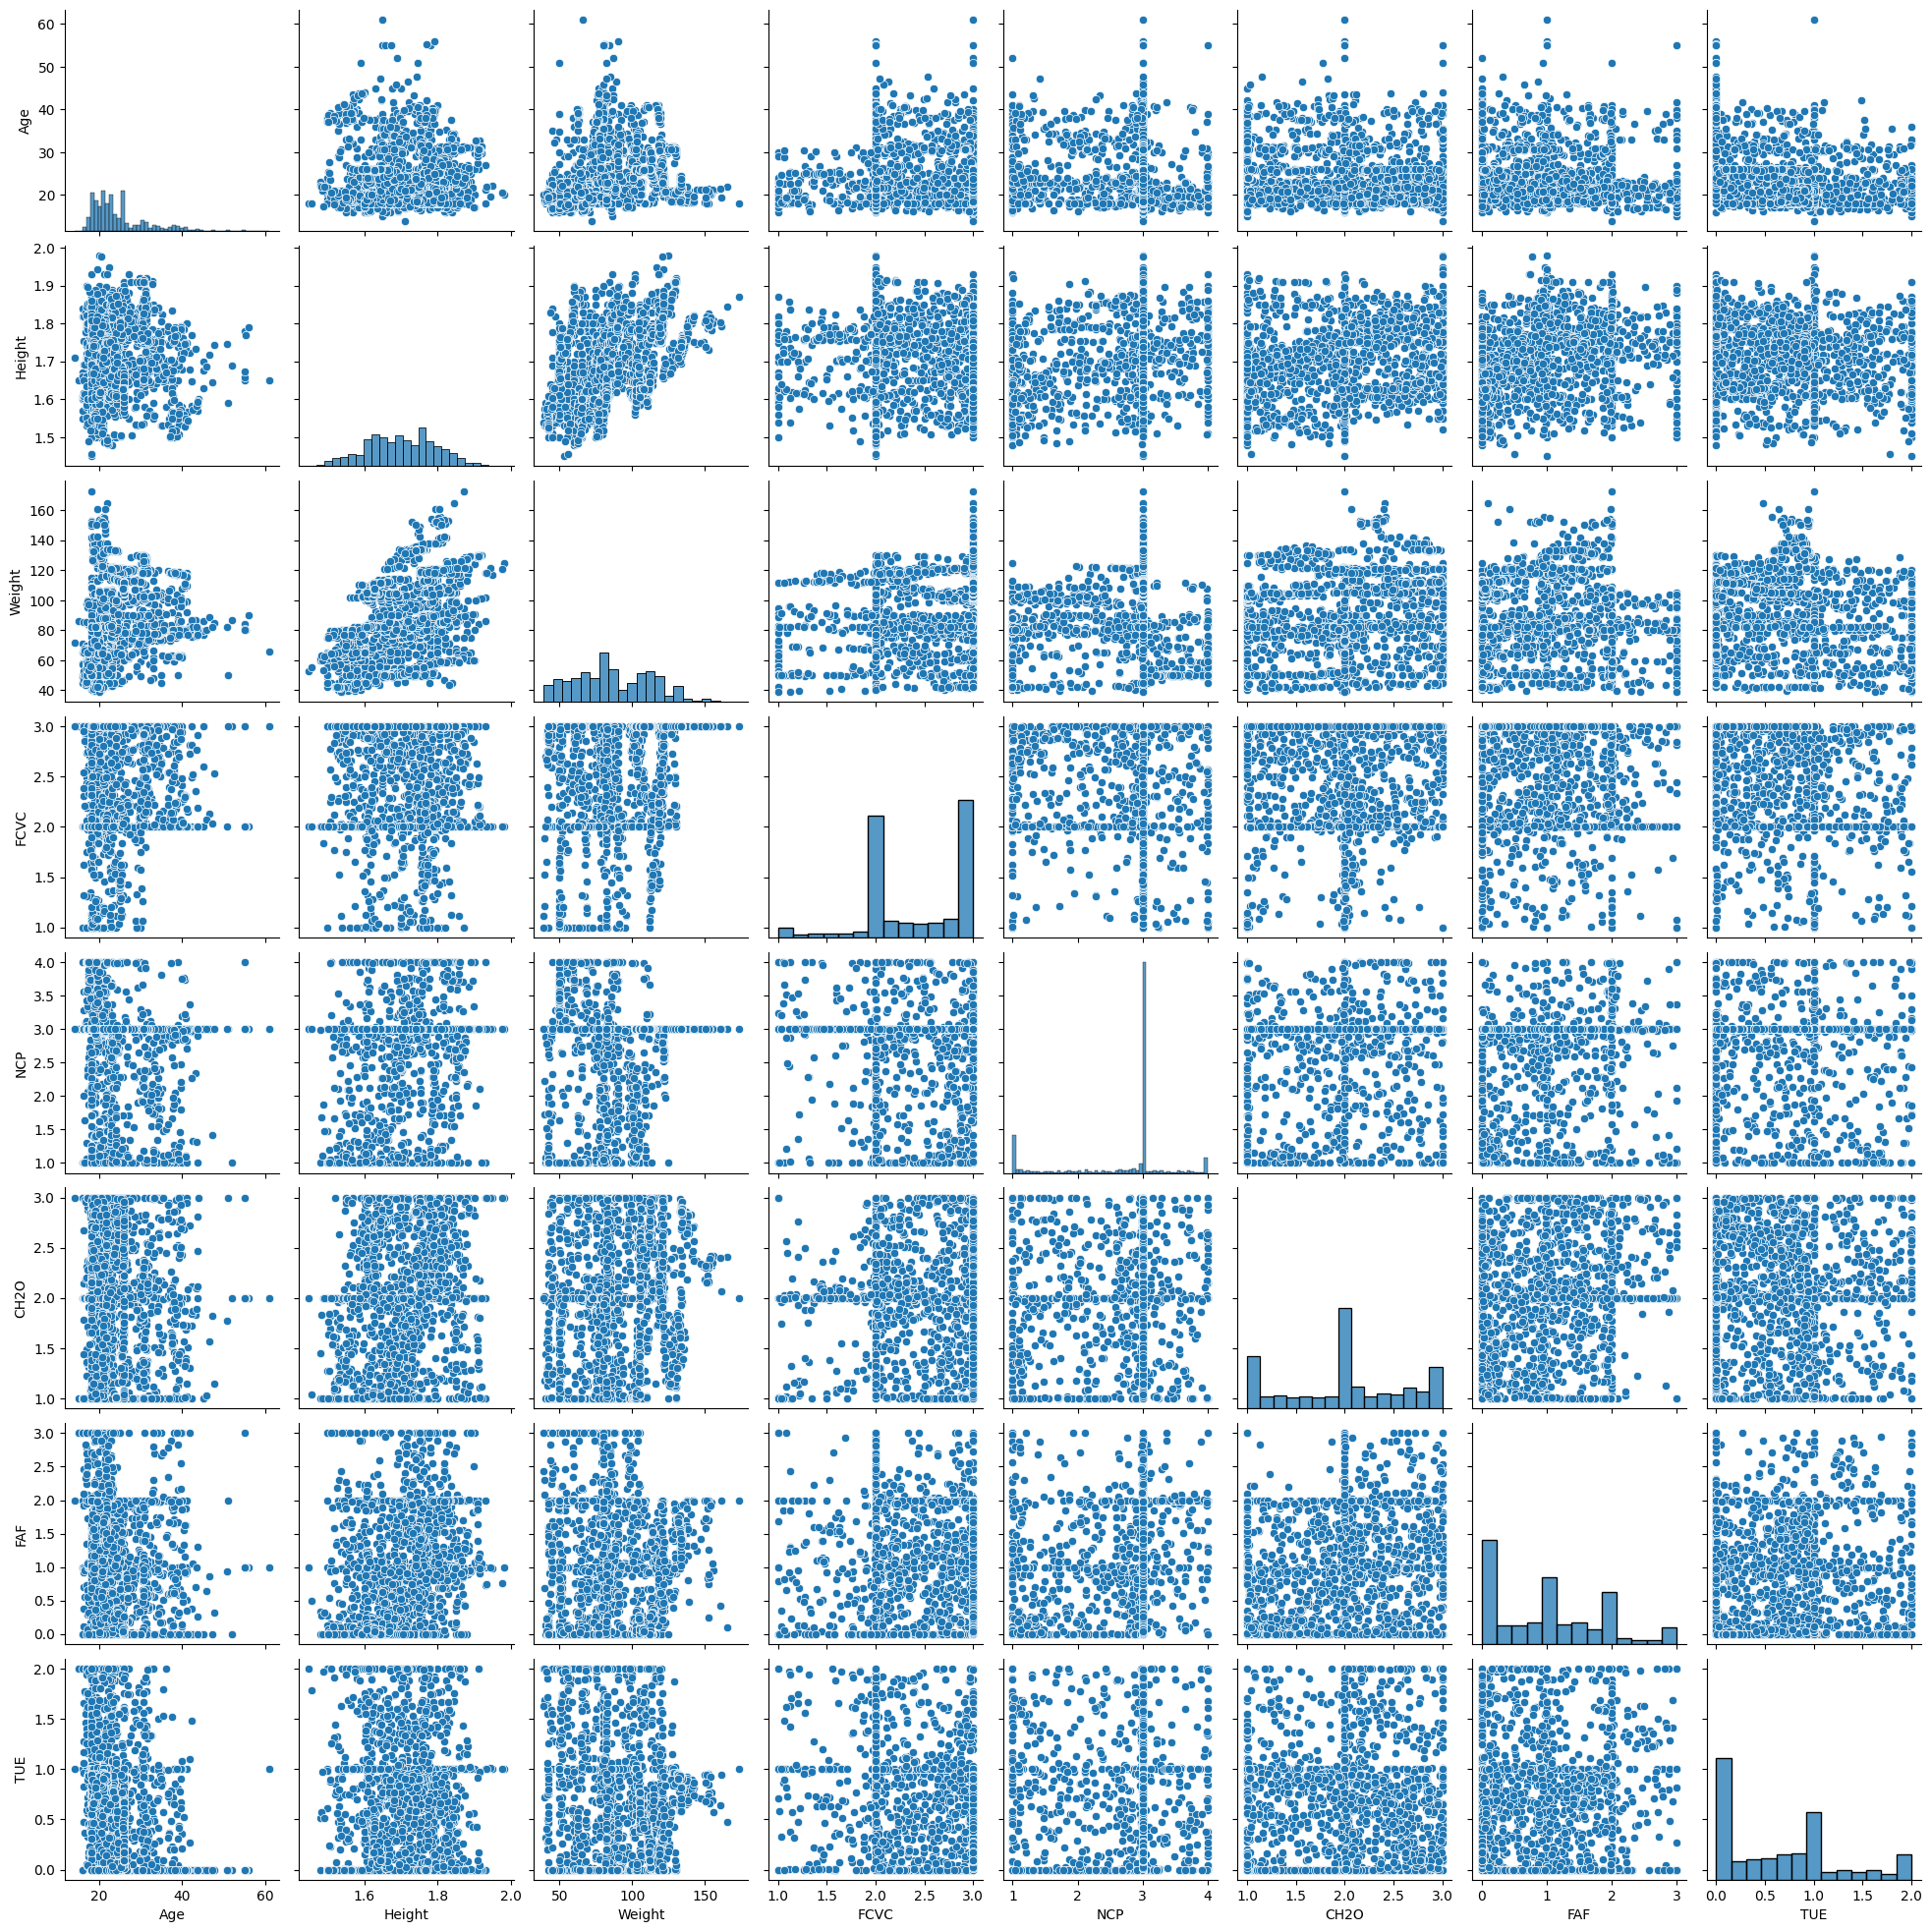

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=[float, int])
sns.pairplot(numeric_df)
plt.show()

In [9]:
correlation_matrix = numeric_df.corr()
display(correlation_matrix)

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
Age,1.000000,-0.025958,0.202560,0.016291,-0.043944,-0.045304,-0.144938,-0.296931
Height,-0.025958,1.000000,0.463136,-0.038121,0.243672,0.213376,0.294709,0.051912
Weight,0.202560,0.463136,1.000000,0.216125,0.107469,0.200575,-0.051436,-0.071561
FCVC,0.016291,-0.038121,0.216125,1.000000,0.042216,0.068461,0.019939,-0.101135
NCP,-0.043944,0.243672,0.107469,0.042216,1.000000,0.057088,0.129504,0.036326
CH2O,-0.045304,0.213376,0.200575,0.068461,0.057088,1.000000,0.167236,0.011965
FAF,-0.144938,0.294709,-0.051436,0.019939,0.129504,0.167236,1.000000,0.058562
TUE,-0.296931,0.051912,-0.071561,-0.101135,0.036326,0.011965,0.058562,1.000000


In [5]:
display(df.describe())

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [6]:
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])

,0


In [8]:
df = df[df['Age'] <= 50]

In [10]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']

# Create training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (1680, 16)
Shape of X_test: (421, 16)
Shape of y_train: (1680,)
Shape of y_test: (421,)


In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# Identify categorical columns
categorical_cols = X_train.select_dtypes(include='object').columns

# Apply one-hot encoding to training data
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
# Apply one-hot encoding to test data
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align columns - very important for consistent feature sets
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# Initialize the Decision Tree Classifier
decision_tree_model = DecisionTreeClassifier(random_state=42)

# Train the model
decision_tree_model.fit(X_train_encoded, y_train)

# Make predictions on the test set
y_pred = decision_tree_model.predict(X_test_encoded)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Decision Tree Classifier Accuracy: {accuracy:.4f}")

Decision Tree Classifier Accuracy: 0.9335


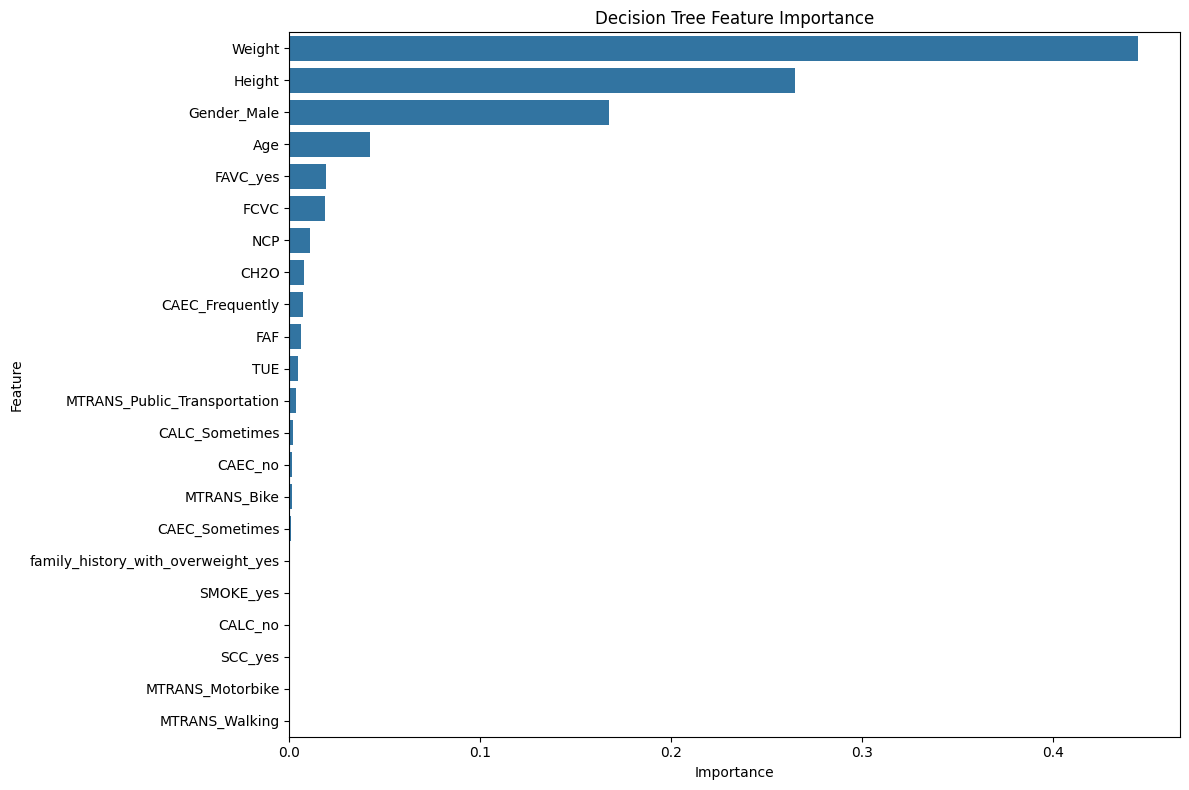

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Get feature importances from the trained model
feature_importances = decision_tree_model.feature_importances_

# Get feature names from the encoded training data
feature_names = X_train_encoded.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Decision Tree Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [12]:
obesity_level_distribution = df['NObeyesdad'].value_counts()
display(obesity_level_distribution)

,count
NObeyesdad,
Obesity_Type_I,350
Obesity_Type_III,324
Obesity_Type_II,297
Overweight_Level_I,289
Normal_Weight,285
Overweight_Level_II,284
Insufficient_Weight,272


In [13]:
from sklearn.metrics import classification_report

# Generate the classification report
report = classification_report(y_test, y_pred)

# Print the report
print(report)

                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.93      0.96        55
      Normal_Weight       0.89      0.92      0.91        64
     Obesity_Type_I       0.90      0.96      0.93        73
    Obesity_Type_II       0.98      0.98      0.98        50
   Obesity_Type_III       1.00      1.00      1.00        61
 Overweight_Level_I       0.86      0.89      0.87        54
Overweight_Level_II       0.93      0.86      0.89        64

           accuracy                           0.93       421
          macro avg       0.94      0.93      0.93       421
       weighted avg       0.94      0.93      0.93       421



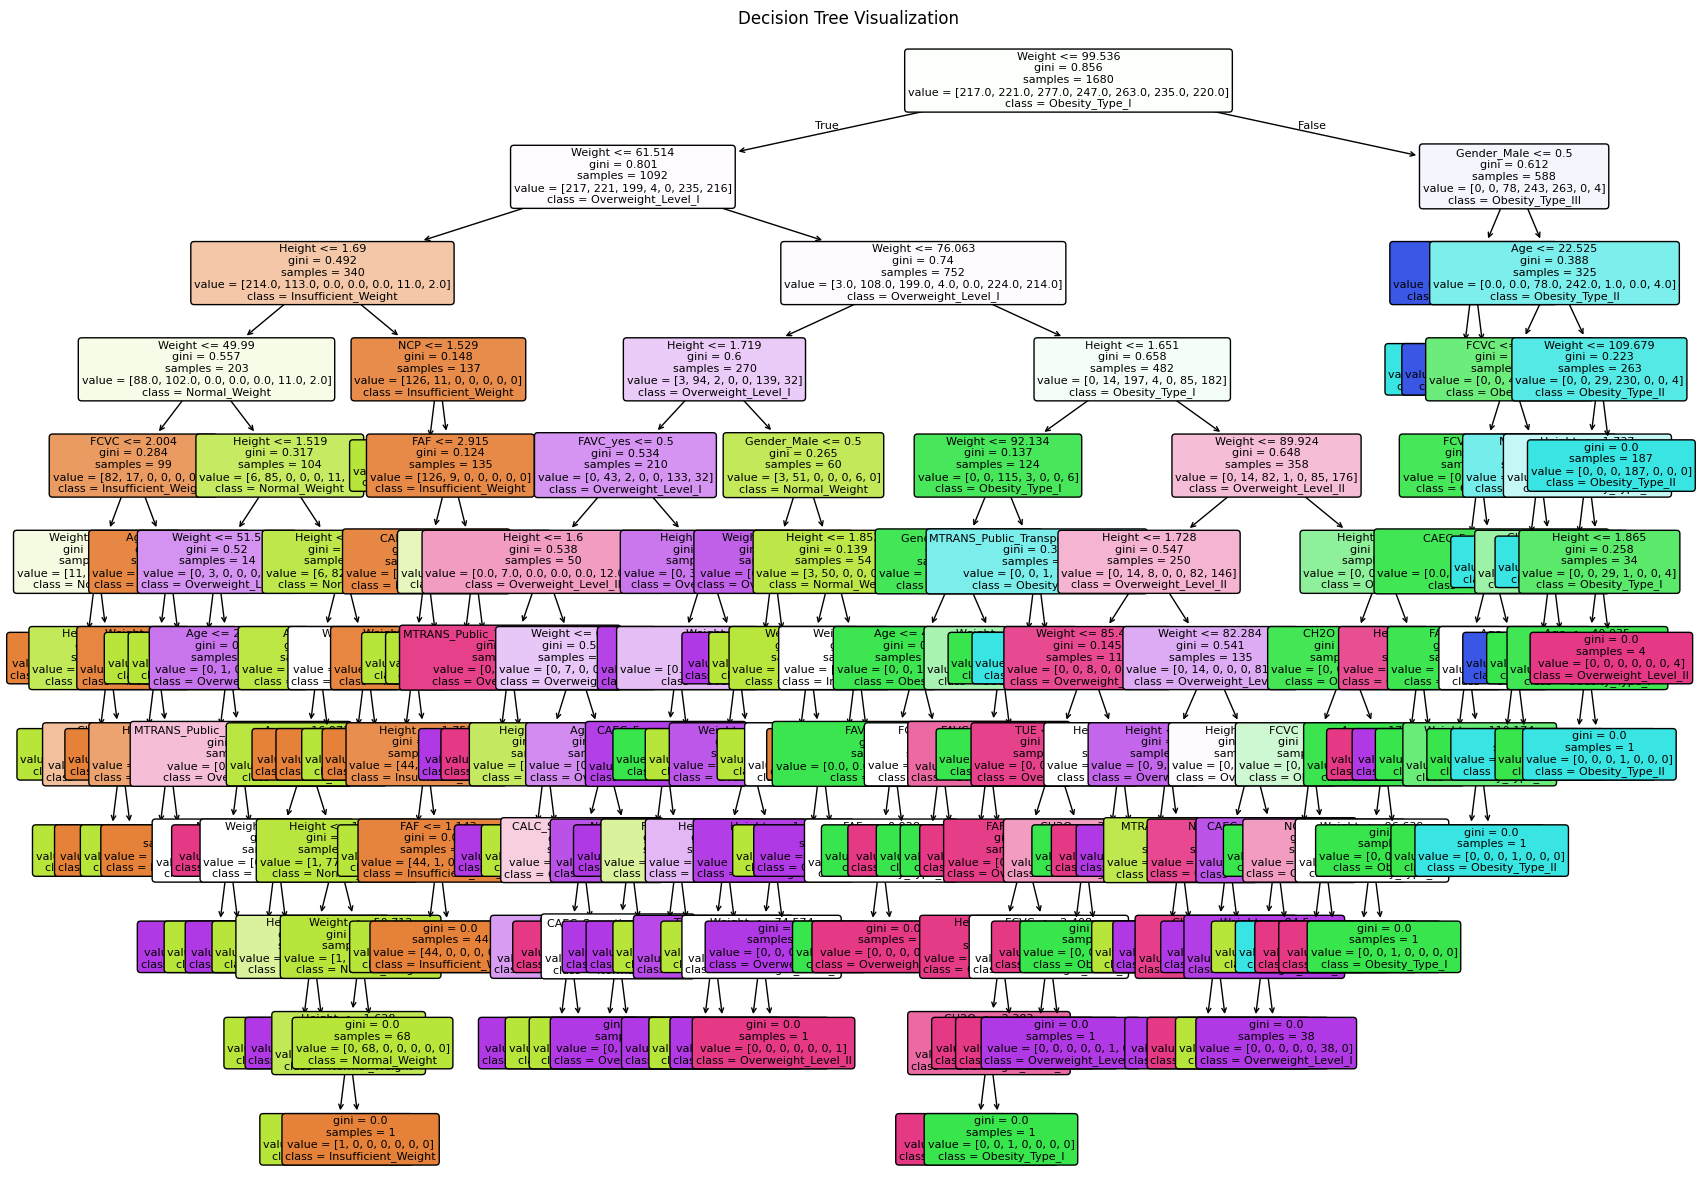

In [15]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 15))
plot_tree(decision_tree_model,
          feature_names=X_train_encoded.columns,
          class_names=decision_tree_model.classes_,
          filled=True,
          rounded=True,
          fontsize=8)
plt.title('Decision Tree Visualization')
plt.show()